In [1]:
%reload_ext autoreload
%autoreload 2

In [217]:
import numpy as np
import pandas as pd
import mat73 as mt
import scipy.io as sio
import matplotlib.pyplot as plt
from scipy import stats

from fppnpx.preprocessing import read_session, load_waveforms, read_bin
from fppnpx.ChannelSignal import ChannelSignal
from fppnpx.plottools import MATMAP, WAVEMAP_PAL2, MISC6_PAL, WF_PAL
from fppnpx.filters import gen_filter
from fppnpx.spectral import multitaper_spectrum, multitaper_spectrogram, spectrum_trunc, spectrum_interp
from fppnpx.decoding import FPPGLM

plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [99]:
# imecpath = Path('/home/mateoumaguing/Documents/MiscData/TibsCFD/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0')
imecpath = "/Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0"

time_window = [204,209]
npxsession = read_session(time_window=time_window, imec_path=imecpath)

Loading session from /Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0
Reading metadata...
Reading channel information...
383 usable channels detected. Use `channel_map` to view usable channels.
Reading cluster information from kilosort...
Session loading complete.


In [100]:
waveformpath = "/Users/mateouma/Downloads/monkey datasets/20230630_DLPFCwaveforms.mat"
waveform_dataset, waveform_means = load_waveforms(waveformpath, npxsession)

Loading waveforms...
138 clusters with good waveforms detected.


In [147]:
tw = 3.5
n_taps = 2*tw - 1
fs = 30000

ch163 = ChannelSignal(163, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=None, time_halfbandwidth_product=tw, verbose=True)

Loading AP signal from channel 163...
Selecting good units...
Reading in time-series...
Notch filtering...
Computing multitapered spectrum...


(300.0, 5000.0)

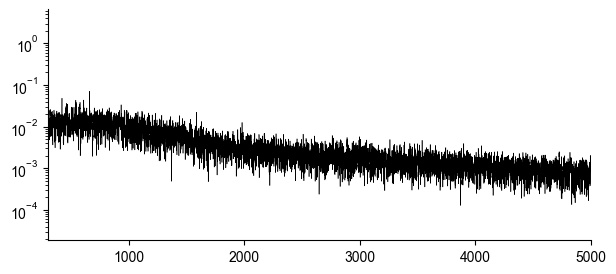

In [102]:
fig,ax = plt.subplots(figsize=(7,3))
ax.semilogy(ch163.mtap_frequencies, ch163.mtap_spectrum, color='k', linewidth=0.4)
ax.set_xlim(300,5e3)

## WaveMAP

In [5]:
from fppnpx.unit_clustering import WaveMAP

In [6]:
# wmc = WaveMAP(random_state=42, resolution=1.5)
wmc = WaveMAP(random_state=99, resolution=1.0, cluster_palette=WAVEMAP_PAL2)
wmc.fit(waveforms=waveform_means, verbose=True)

Computing UMAP: 15 neighbors | 0.1 minimum distance | random_state 99


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Applying Louvain method: 1.0 resolution


/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


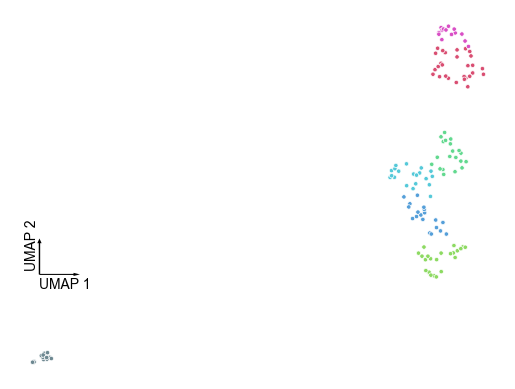

In [7]:
fig,ax = plt.subplots()
wmc.plot_umap(show_clustering_solution=True, ax=ax)

In [36]:
cluster_ids = np.array(list(waveform_dataset.keys()))
cluster_ids

array([ 17,  21,  22,  24,  35,  41,  48,  52,  64,  65,  80,  87,  91,
        95, 105, 116, 117, 123, 125, 129, 130, 135, 139, 140, 146, 150,
       153, 177, 213, 215, 227, 234, 239, 241, 247, 248, 249, 250, 251,
       255, 257, 260, 263, 265, 268, 269, 272, 274, 275, 278, 284, 286,
       287, 291, 292, 296, 298, 306, 310, 311, 313, 314, 315, 317, 322,
       323, 328, 329, 332, 333, 335, 336, 339, 340, 344, 346, 347, 348,
       350, 354, 356, 360, 362, 365, 374, 375, 378, 379, 380, 383, 389,
       392, 393, 396, 397, 398, 401, 403, 405, 410, 417, 418, 419, 423,
       429, 433, 435, 439, 441, 443, 447, 449, 469, 470, 473, 480, 491,
       496, 500, 502, 516, 519, 523, 526, 528, 530, 531, 539, 548, 552,
       554, 556, 557, 561, 572, 583, 585, 587])

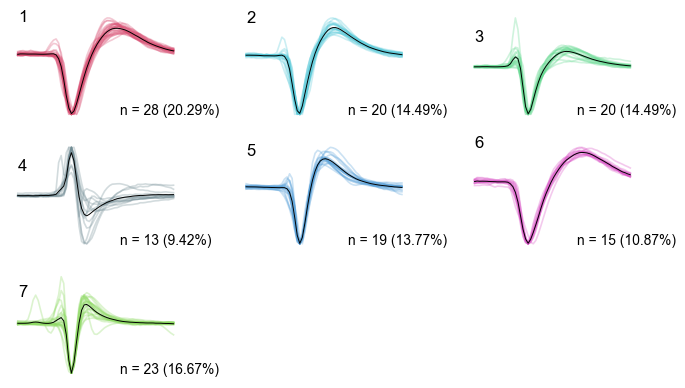

In [17]:
waveform_group_fig = wmc.plot_groups()

## FPP-based inverse modeling can decode dynamic firing rates of populations on a channel

In [195]:
# imecpath = Path('/home/mateoumaguing/Documents/MiscData/TibsCFD/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0')
imecpath = "/Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0"

time_window = [100,123]
npxsession = read_session(time_window=time_window, imec_path=imecpath)

Loading session from /Users/mateouma/Desktop/TIBERIUS_CHKDLAY_DLPFC_NPIX45_063023_g0
Reading metadata...
Reading channel information...
383 usable channels detected. Use `channel_map` to view usable channels.
Reading cluster information from kilosort...
Session loading complete.


In [235]:
waveformpath = "/Users/mateouma/Downloads/monkey datasets/20230630_DLPFCwaveforms.mat"
waveform_dataset, waveform_means = load_waveforms(waveformpath, npxsession)

Loading waveforms...
138 clusters with good waveforms detected.


In [236]:
bs_waveform = []
ns_waveform = []
tp_waveform = []

bs_spectrum = []
ns_spectrum = []
tp_spectrum = []

for i,clust in enumerate(wmc.clustering_solution):
    if clust in [0, 5]: # broad spiking
        bs_waveform.append(waveform_dataset[cluster_ids[i]]["time_filter"])
        bs_spectrum.append(waveform_dataset[cluster_ids[i]]["filter_spectrum"])
    elif clust in [1, 4]: # narrow spiking
        ns_waveform.append(waveform_dataset[cluster_ids[i]]["time_filter"])
        ns_spectrum.append(waveform_dataset[cluster_ids[i]]["filter_spectrum"])
    elif clust in [2, 6]: # triphasic spiking
        tp_waveform.append(waveform_dataset[cluster_ids[i]]["time_filter"])
        tp_spectrum.append(waveform_dataset[cluster_ids[i]]["filter_spectrum"])
frequency_axis = waveform_dataset[cluster_ids[i]]["filter_freq_axis"]

bs_waveform = np.array(bs_waveform).mean(axis=0)
ns_waveform = np.array(ns_waveform).mean(axis=0)
tp_waveform = np.array(tp_waveform).mean(axis=0)

bs_spectrum = np.array(bs_spectrum).mean(axis=0)
ns_spectrum = np.array(ns_spectrum).mean(axis=0)
tp_spectrum = np.array(tp_spectrum).mean(axis=0)

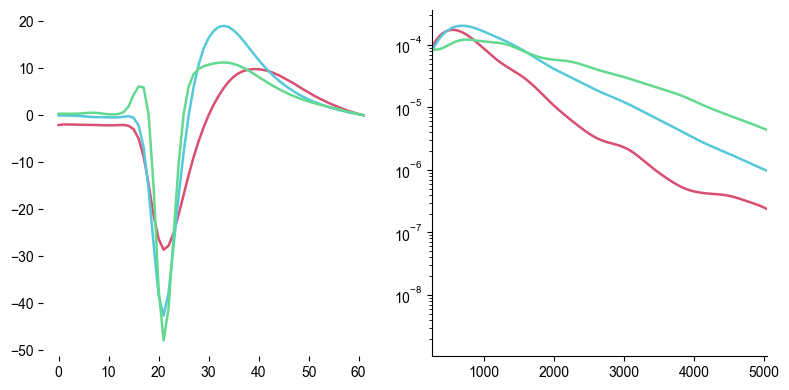

In [237]:
fig,ax = plt.subplots(1,2, figsize=(8,4))
ax[0].plot(bs_waveform[:62], color=WF_PAL[0], linewidth=1.8)
ax[0].plot(ns_waveform[:62], color=WF_PAL[1], linewidth=1.8)
ax[0].plot(tp_waveform[:62], color=WF_PAL[2], linewidth=1.8)
ax[0].spines['left'].set_visible(False)
ax[0].spines['bottom'].set_visible(False)
# ax[0].set(xticks=[],yticks=[])

ax[1].semilogy(frequency_axis, bs_spectrum, color=WF_PAL[0], linewidth=1.8)
ax[1].semilogy(frequency_axis, ns_spectrum, color=WF_PAL[1], linewidth=1.8)
ax[1].semilogy(frequency_axis, tp_spectrum, color=WF_PAL[2], linewidth=1.8)
ax[1].set_xlim(250, 5050)

fig.tight_layout()

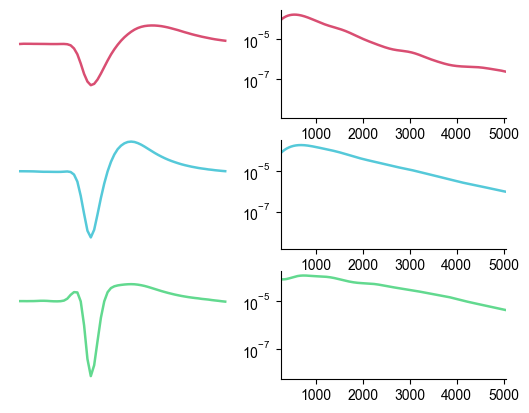

In [238]:
fig,ax = plt.subplots(3,2)

ax[0,0].plot(bs_waveform[:62], linewidth=1.8, color=WF_PAL[0])
ax[0,1].semilogy(frequency_axis, bs_spectrum, linewidth=1.8, color=WF_PAL[0])

ax[1,0].plot(ns_waveform[:62], linewidth=1.8, color=WF_PAL[1])
ax[1,1].semilogy(frequency_axis, ns_spectrum, linewidth=1.8, color=WF_PAL[1])

ax[2,0].plot(tp_waveform[:62], linewidth=1.8, color=WF_PAL[2])
ax[2,1].semilogy(frequency_axis, tp_spectrum, linewidth=1.8, color=WF_PAL[2])

for i in range(3):
    ax[i,0].spines['left'].set_visible(False)
    ax[i,0].spines['bottom'].set_visible(False)
    ax[i,0].set_ylim(-50,20)
    ax[i,0].set(xticks=[],yticks=[])

    ax[i,1].set_xlim(250, 5050)

In [234]:
ch163 = ChannelSignal(163, session_dataset=npxsession, bandtype='AP', waveform_dataset=waveform_dataset, notch_filt=1, bandpass_filt=None, time_halfbandwidth_product=tw, verbose=True)

Loading AP signal from channel 163...
Selecting good units...
Reading in time-series...
Notch filtering...
Computing multitapered spectrum...


broad_spiking_clusts = [0,5]

narrow_spiking_clusts = [1,4]

triphasic_spiking_clusts = [2,6]

In [ ]:
wm_to_grouped = {
    0: 'broad',
    1: 'narrow',
    2: 'triphasic',
    4: 'narrow',
    5: 'broad',
    6: 'triphasic'
}

grouped_to_idx = {
    'broad': 0,
    'narrow': 1,
    'triphasic':2
}
   

In [271]:
spikes_conv_list = []
spikes_mask_list = []

bs_spikes = []
ns_spikes = []
tp_spikes = []

for i,unit in enumerate(ch163.detected_units):
    cluster_idx, = np.where(cluster_ids == unit)[0]
    wavemap_clust = wmc.clustering_solution[cluster_idx]
    waveform_grouping = wm_to_grouped[wavemap_clust]
    print(f"CLUST ID {unit}, WMC {wavemap_clust}, GROUP {waveform_grouping}")

    unit_spike_train = np.zeros_like(ch163.time_series)
    unit_spike_train[npxsession['cluster_spike_times'][unit]] = 1
    if waveform_grouping == 'broad':
        bs_spikes.append(unit_spike_train)
    elif waveform_grouping == 'narrow':
        ns_spikes.append(unit_spike_train)
    elif waveform_grouping == 'triphasic':
        tp_spikes.append(unit_spike_train)

    unit_spikes_conv = np.convolve(unit_spike_train, waveform_dataset[unit]['time_filter'][:62])[20:-41]
    spikes_mask_list.append(unit_spikes_conv == 0)
    spikes_conv_list.append(unit_spikes_conv)

bs_spikes = np.sum(np.array(bs_spikes), axis=0)
ns_spikes = np.sum(np.array(ns_spikes), axis=0)
tp_spikes = np.sum(np.array(tp_spikes), axis=0)
total_time_series = np.sum(np.array(spikes_conv_list), axis=0)

CLUST ID 286, WMC 4, GROUP narrow
CLUST ID 287, WMC 6, GROUP triphasic
CLUST ID 291, WMC 4, GROUP narrow
CLUST ID 292, WMC 0, GROUP broad
CLUST ID 296, WMC 1, GROUP narrow
CLUST ID 298, WMC 1, GROUP narrow


(110.0, 111.0)

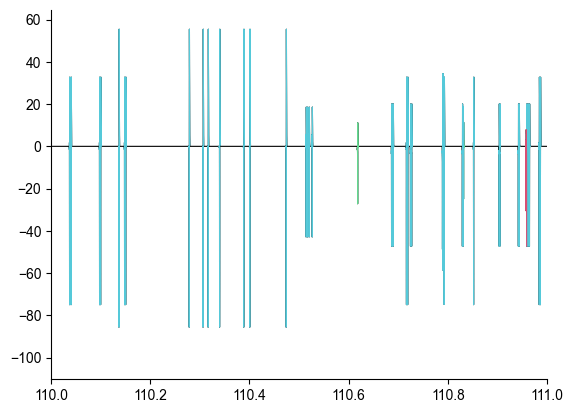

In [260]:
fig,ax = plt.subplots()
# ch163.plot_time_series(ax=ax)
ax.plot(ch163.time_axis, total_time_series, color='k', linewidth=0.8)
for i,unit in enumerate(ch163.detected_units):
    cluster_idx, = np.where(cluster_ids == unit)[0]
    wavemap_clust = wmc.clustering_solution[cluster_idx]
    waveform_grouping = wm_to_grouped[wavemap_clust]

    time_series_excerpt = total_time_series.copy()
    time_series_excerpt[spikes_mask_list[i]] = np.nan
    ax.plot(ch163.time_axis, time_series_excerpt, color=WF_PAL[grouped_to_idx[waveform_grouping]], linewidth=0.8)

ax.set_xlim(110,111)

(110.0, 111.0)

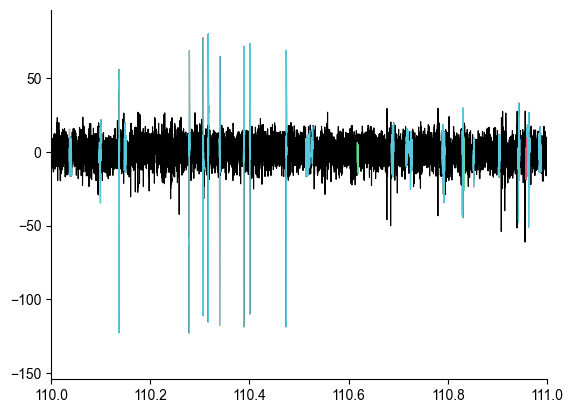

In [261]:
fig,ax = plt.subplots()
# ch163.plot_time_series(ax=ax)
ax.plot(ch163.time_axis, ch163.time_series, color='k', linewidth=0.8)
for i,unit in enumerate(ch163.detected_units):
    cluster_idx, = np.where(cluster_ids == unit)[0]
    time_series_excerpt = ch163.time_series.copy()
    time_series_excerpt[spikes_mask_list[i]] = np.nan
    ax.plot(ch163.time_axis, time_series_excerpt, color=WF_PAL[grouped_to_idx[wm_to_grouped[wmc.clustering_solution[cluster_idx]]]], linewidth=0.8)
ax.set_xlim(110,111)

In [282]:
def firing_rates_from_spike_counts(spike_counts, fs=30000, win_len=0.5):
    firing_rate_time_axis = []
    firing_rates = []
    sample_step = int(fs*win_len)
    curr_samp = 0
    curr_time = 0

    while curr_samp < (len(spike_counts) - sample_step):
        end_idx = curr_samp + sample_step
        firing_rate_time_axis.append(curr_time)
        firing_rates.append(np.sum(spike_counts[curr_samp:end_idx]) / win_len)
        curr_time += win_len
        curr_samp += sample_step

    return np.array(firing_rates), np.array(firing_rate_time_axis)

In [286]:
bs_firing_rates,fr_time_axis = firing_rates_from_spike_counts(bs_spikes)
ns_firing_rates,fr_time_axis = firing_rates_from_spike_counts(ns_spikes)
tp_firing_rates,fr_time_axis = firing_rates_from_spike_counts(tp_spikes)

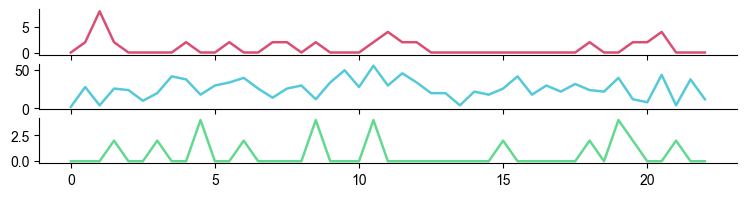

In [289]:
fig,ax = plt.subplots(3,1, figsize=(9,2))
ax[0].plot(fr_time_axis,bs_firing_rates, linewidth=1.8, color=WF_PAL[0])
ax[1].plot(fr_time_axis,ns_firing_rates, linewidth=1.8, color=WF_PAL[1])
ax[2].plot(fr_time_axis,tp_firing_rates, linewidth=1.8, color=WF_PAL[2])

In [352]:
filter_spectrum_list = [bs_spectrum, ns_spectrum, tp_spectrum]
observed_rates_groups = [bs_firing_rates, ns_firing_rates, tp_firing_rates]
observed_rates_groups = np.array(observed_rates_groups).T

fr_preds = []
spectrum_preds = []
theoretical_spectrogram = []

sample_step = int(fs*0.5)
curr_samp = 0
t = 0

while t < len(fr_time_axis):
    end_idx = curr_samp + sample_step
    ts_excerpt = total_time_series[curr_samp:end_idx]
    ts_excerpt_time_axis = ch163.time_axis[curr_samp:end_idx]

    model_t = FPPGLM()
    model_t.fit(ts_excerpt, ts_excerpt_time_axis,
                filter_spectrum_list, frequency_axis, observed_rates_groups[t],
                (300,5000), fs=fs, time_halfbandwidth_product=1, start_time=fr_time_axis[t])
    model_t.predict()

    fr_preds.append(model_t.estimated_rates)
    theoretical_spectrogram.append(model_t.theoretical_spectrum_interpolated)
    spectrum_preds.append(model_t.predicted_spectrum)

    curr_samp += sample_step
    t += 1

fr_preds = np.array(fr_preds)
theoretical_spectrogram = np.array(theoretical_spectrogram)
spectrum_preds = np.array(spectrum_preds)

/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain o

Text(0.5, 0.98, 'Predicted from Isolated')

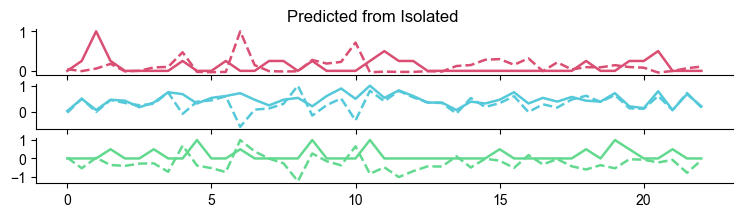

In [415]:
# normalized firing rates
fig,ax = plt.subplots(3,1, figsize=(9,2))
ax[0].plot(fr_time_axis,bs_firing_rates / np.max(bs_firing_rates), linewidth=1.8, color=WF_PAL[0])
ax[1].plot(fr_time_axis,ns_firing_rates / np.max(ns_firing_rates), linewidth=1.8, color=WF_PAL[1])
ax[2].plot(fr_time_axis,tp_firing_rates / np.max(tp_firing_rates), linewidth=1.8, color=WF_PAL[2])

ax[0].plot(fr_time_axis,fr_preds[:,0] / np.max(fr_preds[:,0]), linewidth=1.8, linestyle='--', color=WF_PAL[0])
ax[1].plot(fr_time_axis,fr_preds[:,1] / np.max(fr_preds[:,1]), linewidth=1.8, linestyle='--', color=WF_PAL[1])
ax[2].plot(fr_time_axis,fr_preds[:,2] / np.max(fr_preds[:,2]), linewidth=1.8, linestyle='--', color=WF_PAL[2])

fig.suptitle("Predicted from Isolated")

In [420]:
fr_preds_raw = []

sample_step = int(fs*0.5)
curr_samp = 0
t = 0

while t < len(fr_time_axis):
    end_idx = curr_samp + sample_step
    ts_excerpt = ch163.time_series[curr_samp:end_idx]
    ts_excerpt_time_axis = ch163.time_axis[curr_samp:end_idx]

    model_t = FPPGLM()
    model_t.fit(ts_excerpt, ts_excerpt_time_axis,
                filter_spectrum_list, frequency_axis, observed_rates_groups[t],
                (300,5000), fs=fs, time_halfbandwidth_product=1, start_time=fr_time_axis[t])
    model_t.predict()

    fr_preds_raw.append(model_t.estimated_rates)

    curr_samp += sample_step
    t += 1

fr_preds_raw = np.array(fr_preds_raw)

/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "
/opt/miniconda3/envs/wavemapspec/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The Identity link function does not respect the domain o

Text(0.5, 0.98, 'Predicted from Raw')

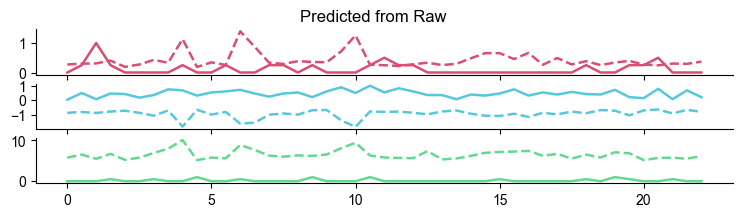

In [421]:
# normalized firing rates
fig,ax = plt.subplots(3,1, figsize=(9,2))
ax[0].plot(fr_time_axis,bs_firing_rates / np.max(bs_firing_rates), linewidth=1.8, color=WF_PAL[0])
ax[1].plot(fr_time_axis,ns_firing_rates / np.max(ns_firing_rates), linewidth=1.8, color=WF_PAL[1])
ax[2].plot(fr_time_axis,tp_firing_rates / np.max(tp_firing_rates), linewidth=1.8, color=WF_PAL[2])

ax[0].plot(fr_time_axis,fr_preds_raw[:,0] / np.max(fr_preds[:,0]), linewidth=1.8, linestyle='--', color=WF_PAL[0])
ax[1].plot(fr_time_axis,fr_preds_raw[:,1] / np.max(fr_preds[:,1]), linewidth=1.8, linestyle='--', color=WF_PAL[1])
ax[2].plot(fr_time_axis,fr_preds_raw[:,2] / np.max(fr_preds[:,2]), linewidth=1.8, linestyle='--', color=WF_PAL[2])

fig.suptitle("Predicted from Raw")

In [410]:
mt_spectrogram = multitaper_spectrogram(total_time_series, fs, 1, 0.5, 0.5)
mt_power = mt_spectrogram.power().squeeze()
mt_freqs = mt_spectrogram.frequencies

mt_spectrogram_trunc = mt_power[:,mt_freqs < 5000]

In [417]:
mt_spectrogram_raw = multitaper_spectrogram(ch163.time_series, fs, 1, 0.5, 0.5)
mt_power_raw = mt_spectrogram_raw.power().squeeze()
mt_freqs_raw = mt_spectrogram_raw.frequencies

mt_spectrogram_raw_trunc = mt_power_raw[:,mt_freqs_raw < 5000]

/var/folders/nm/w2ptffz16jvdj7330zc_2btw0000gp/T/ipykernel_2199/2642882395.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_yticklabels(np.arange(-1000,6000,1000))
/var/folders/nm/w2ptffz16jvdj7330zc_2btw0000gp/T/ipykernel_2199/2642882395.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(np.arange(-1000,6000,1000))
/var/folders/nm/w2ptffz16jvdj7330zc_2btw0000gp/T/ipykernel_2199/2642882395.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2].set_yticklabels(np.arange(-1000,6000,1000))
/var/folders/nm/w2ptffz16jvdj7330zc_2btw0000gp/T/ipykernel_2199/2642882395.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[3

Text(0.5, 1.0, 'Raw MT Spectrogram')

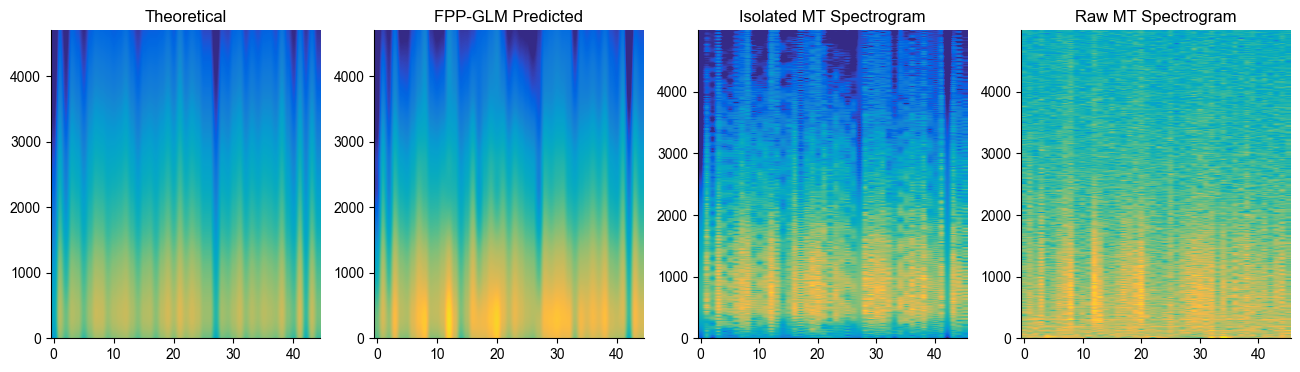

In [419]:
fig,ax = plt.subplots(1,4, figsize=(16,4))
ax[0].imshow(10*np.log10(theoretical_spectrogram.T), cmap=MATMAP, aspect='auto', vmin=-50, vmax=-10)
ax[0].set_yticklabels(np.arange(-1000,6000,1000))
ax[0].invert_yaxis()
ax[0].set_title("Theoretical")

ax[1].imshow(10*np.log10(spectrum_preds.T), cmap=MATMAP, aspect='auto', vmin=-50, vmax=-10)
ax[1].set_yticklabels(np.arange(-1000,6000,1000))
ax[1].invert_yaxis()
ax[1].set_title("FPP-GLM Predicted")

ax[2].imshow(10*np.log10(mt_spectrogram_trunc.T), cmap=MATMAP, aspect='auto', vmin=-50, vmax=-10)
ax[2].set_yticklabels(np.arange(-1000,6000,1000))
ax[2].invert_yaxis()
ax[2].set_title("Isolated MT Spectrogram")

ax[3].imshow(10*np.log10(mt_spectrogram_raw_trunc.T), cmap=MATMAP, aspect='auto', vmin=-50, vmax=-10)
ax[3].set_yticklabels(np.arange(-1000,6000,1000))
ax[3].invert_yaxis()
ax[3].set_title("Raw MT Spectrogram")